In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import glob
import os

**Note (provenance-only notebook):** this notebook reads raw per-session
recordings from an external drive path
(`/media/caveman/Vorchard1/jaleesa_unsteady/fly_data/...`) that is not part of
this repository's `raw_data/` and is not published on Dryad. It documents how
the date-stamped `*_SHAM_AUGMENTED.parquet` files and the merged
`flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED_merged.parquet`
(already present in this directory and in `raw_data/`) were produced. It is
not expected to run on another machine and does not need to be re-run to
reproduce the figures.

In [2]:
from braid_analysis import braid_slicing

In [3]:
def get_preprocessed_file(directory, key='*_preprocessed.hdf'):
    files = glob.glob(os.path.join(directory, key))
    if len(files) == 0:
        raise FileNotFoundError(f'No _preprocessed.hdf file found in {directory}')
    if len(files) > 1:
        raise ValueError(f'Multiple _preprocessed.hdf files found in {directory}')
    return files[0]

In [4]:
dirname = '20240516_c1xwt_horizontal_split_topon'

In [5]:
fname = get_preprocessed_file('/media/caveman/Vorchard1/jaleesa_unsteady/fly_data/horizontal_split_top_on/' + dirname + '/preprocessed_data/')
df_flies = pd.read_hdf(fname)

fname = get_preprocessed_file('/media/caveman/Vorchard1/jaleesa_unsteady/fly_data/horizontal_split_top_on/' + dirname + '/preprocessed_data/', 'optotrigger_light_stimulus.hdf')
df_lights = pd.read_hdf(fname)

FileNotFoundError: No _preprocessed.hdf file found in /media/caveman/Vorchard1/jaleesa_unsteady/fly_data/horizontal_split_top_on/20240516_c1xwt_horizontal_split_topon/preprocessed_data/

In [6]:
df_flies.keys()

Index(['obj_id', 'frame', 'timestamp', 'x', 'y', 'z', 'xvel', 'yvel', 'zvel',
       'P00', 'P01', 'P02', 'P11', 'P12', 'P22', 'P33', 'P44', 'P55',
       'obj_id_unique', 'speed_xy', 'course', 'course_smoothish',
       'ang_vel_smoothish'],
      dtype='object')

In [7]:
df_lights.keys()

Index(['frame', 'flash_frame', 'obj_id_triggered', 'trigger_exp',
       'trigger_description', 'lights_on_function', 'lights_on', 'duration',
       'intensity'],
      dtype='object')

# Get long objids 

In [8]:
long_objids = braid_slicing.get_long_obj_ids_fast_pandas(df_flies, obj_id_key='obj_id_unique', length=500)

In [9]:
df_flies = df_flies[df_flies.obj_id_unique.isin(long_objids)]

In [10]:
def get_trajectories_in_volume(df, zmin=0.1, zmax=0.4, ymin=-0.1, ymax=0.1, xmin=-0.3, xmax=0.3):
    in_volume = df[
        (df['x'] >= xmin) & (df['x'] <= xmax) &
        (df['y'] >= ymin) & (df['y'] <= ymax) &
        (df['z'] >= zmin) & (df['z'] <= zmax)
    ]
    return in_volume['obj_id_unique'].unique().tolist()

In [11]:
obj_ids_in_volume = get_trajectories_in_volume(df_flies)

In [12]:
df_flies = df_flies[df_flies.obj_id_unique.isin(obj_ids_in_volume)]

In [13]:
len(df_flies.obj_id_unique.unique())

358

In [14]:
def create_flash_aligned_trajectories(df_flies, zmin=0.07, zmax=0.4, ymin=-0.15, ymax=0.15, 
                                       xmin=-0.2, xmax=0.2, fps=100,
                                       frames_before=20, min_frames_after=300, max_frames_after=500):
    
    total_length = frames_before + 1 + max_frames_after  # 521 frames total
    result_dfs = []
    
    for obj_id, traj in df_flies.groupby('obj_id_unique'):
        traj = traj.sort_values('frame').reset_index(drop=True)
        
        # Find first frame inside volume
        in_volume = (
            (traj['x'] >= xmin) & (traj['x'] <= xmax) &
            (traj['y'] >= ymin) & (traj['y'] <= ymax) &
            (traj['z'] >= zmin) & (traj['z'] <= zmax)
        )
        
        if not in_volume.any():
            continue
        
        flash_idx = in_volume.idxmax()  # first True index
        
        # Check we have enough frames before
        if flash_idx < frames_before:
            continue
        
        # Slice: 20 before, flash frame, up to 500 after
        start_idx = flash_idx - frames_before
        end_idx = flash_idx + max_frames_after + 1  # +1 for inclusive slice
        
        frames_after = len(traj) - flash_idx - 1
        
        # Remove if fewer than min_frames_after
        if frames_after < min_frames_after:
            continue
        
        traj_trimmed = traj.iloc[start_idx:end_idx].copy().reset_index(drop=True)
        flash_frame_num = traj_trimmed.loc[frames_before, 'frame']
        
        # Add flash_frame bool column
        traj_trimmed['flash_frame'] = False
        traj_trimmed.loc[frames_before, 'flash_frame'] = True
        
        # Add time_relative_to_flash
        traj_trimmed['time_relative_to_flash'] = (traj_trimmed['frame'] - flash_frame_num) / fps
        
        # Pad with NaNs if shorter than total_length
        if len(traj_trimmed) < total_length:
            pad_length = total_length - len(traj_trimmed)
            last_frame = traj_trimmed['frame'].iloc[-1]
            pad_frames = pd.DataFrame({
                col: [np.nan] * pad_length for col in traj_trimmed.columns
            })
            # Fill in frame and time columns for padding
            pad_frame_nums = [last_frame + i + 1 for i in range(pad_length)]
            pad_frames['frame'] = pad_frame_nums
            pad_frames['time_relative_to_flash'] = [(f - flash_frame_num) / fps for f in pad_frame_nums]
            pad_frames['obj_id_unique'] = obj_id
            pad_frames['flash_frame'] = False
            traj_trimmed = pd.concat([traj_trimmed, pad_frames], ignore_index=True)
        
        result_dfs.append(traj_trimmed)
    
    if len(result_dfs) == 0:
        return pd.DataFrame()
    
    return pd.concat(result_dfs, ignore_index=True)

In [15]:
df_flies_aligned = create_flash_aligned_trajectories(df_flies)

In [16]:
df_flies_aligned

,obj_id,frame,timestamp,x,y,z,xvel,yvel,zvel,P00,...,P33,P44,P55,obj_id_unique,speed_xy,course,course_smoothish,ang_vel_smoothish,flash_frame,time_relative_to_flash
0,1054.0,711944,1.715830e+09,-0.166068,0.110665,0.410533,-0.000246,-0.054332,-0.044386,0.000001,...,0.019880,0.019276,0.030793,20240515_182700_1054,0.054332,-1.575330,-1.564938,-16.867188,False,-0.20
1,1054.0,711945,1.715830e+09,-0.166208,0.110067,0.410382,-0.008038,-0.056933,-0.030894,0.000001,...,0.019921,0.019299,0.030818,20240515_182700_1054,0.057497,-1.711051,-1.694869,-7.466647,False,-0.19
2,1054.0,711946,1.715830e+09,-0.166333,0.109387,0.410315,-0.009851,-0.063663,-0.019413,0.000001,...,0.019857,0.019229,0.030791,20240515_182700_1054,0.064421,-1.724320,-1.714271,0.524460,False,-0.18
3,1054.0,711947,1.715830e+09,-0.166366,0.108626,0.410297,-0.004492,-0.071689,-0.010724,0.000002,...,0.020626,0.019792,0.033026,20240515_182700_1054,0.071830,-1.633377,-1.684380,2.812417,False,-0.17
4,1054.0,711948,1.715830e+09,-0.166510,0.107986,0.410419,-0.009766,-0.065602,-0.000014,0.000001,...,0.019816,0.019232,0.030558,20240515_182700_1054,0.066325,-1.718572,-1.658023,2.240616,False,-0.16
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
116178,NaN,678863,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,20240515_182700_988,NaN,NaN,NaN,NaN,False,4.96
116179,NaN,678864,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,20240515_182700_988,NaN,NaN,NaN,NaN,False,4.97
116180,NaN,678865,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,20240515_182700_988,NaN,NaN,NaN,NaN,False,4.98
116181,NaN,678866,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,20240515_182700_988,NaN,NaN,NaN,NaN,False,4.99


In [17]:
len(df_flies_aligned.obj_id_unique.unique())

223

In [18]:
def get_trajectories_lights_off(df_flies, df_lights, n_frames=1000):
    result = []
    for obj_id, traj in df_flies.groupby('obj_id_unique'):
        first_frame = traj['frame'].min()
        last_frame = traj['frame'].max()
        
        # Check frames from 1000 before trajectory start through end of trajectory
        lights = df_lights[
            (df_lights['frame'] >= first_frame - n_frames) & 
            (df_lights['frame'] <= last_frame)
        ]['lights_on']
        
        if len(lights) > 0 and (lights == 0).all():
            result.append(obj_id)
    return result

In [19]:
obj_id_sham_candidates = get_trajectories_lights_off(df_flies_aligned, df_lights)

In [20]:
len(obj_id_sham_candidates)

117

In [21]:
df_flies_aligned_sham = df_flies_aligned[df_flies_aligned.obj_id_unique.isin(obj_id_sham_candidates)].copy()

In [22]:
def get_trajectories_below_z(df_flies, zmax=0.27):
    below_z = df_flies.groupby('obj_id_unique')['z'].max()
    return below_z[below_z < zmax].index.tolist()

In [23]:
obj_ids = get_trajectories_below_z(df_flies_aligned_sham)

In [24]:
len(obj_ids)

2

In [25]:
df_flies_aligned_sham = df_flies_aligned_sham[df_flies_aligned_sham.obj_id_unique.isin(obj_ids)].copy()

In [26]:
df_flies_aligned_sham.loc[:, 'obj_id_unique_event'] = df_flies_aligned_sham.obj_id_unique.values

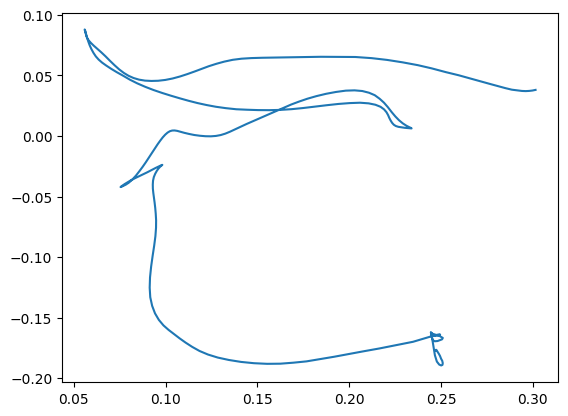

In [27]:
if len(df_flies_aligned_sham.obj_id_unique_event.unique()) > 0:
        
    df_flies_aligned_sham.loc[:,'duration'] = 0
    df_flies_aligned_sham.loc[:,'intensity'] = 0
    df_flies_aligned_sham.loc[:,'trigger_descrition'] = 'augmented sham'
    df_flies_aligned_sham.loc[:,'lights_on_function'] = 'none'
    df_flies_aligned_sham.loc[:,'lights_on'] = 0

    df_flies_aligned_sham.to_parquet(dirname.split('_')[0] + '_' + 'flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED.parquet')

    obj_id = df_flies_aligned_sham.obj_id_unique_event.unique()[0]
    trajec = df_flies_aligned_sham[df_flies_aligned_sham.obj_id_unique_event==obj_id]

    plt.plot(trajec.x, trajec.y)

# Merge individual parquets

In [28]:
def get_preprocessed_files(directory, key='*_preprocessed.hdf'):
    files = glob.glob(os.path.join(directory, key))
    return files

In [29]:
files = get_preprocessed_files('.', key='*flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED.parquet')

In [30]:
files

['./20240513_flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED.parquet',
 './20240516_flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED.parquet',
 './20240111_flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED.parquet',
 './20240514_flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED.parquet',
 './20240110_flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED.parquet',
 './20240109_flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED.parquet']

In [31]:
dfs = []
for file in files:
    df = pd.read_parquet(file)
    dfs.append(df)

df_combined = pd.concat(dfs)

In [32]:
df_combined.to_parquet('../../../../../Data/Experimental_Fly_Data/flies_splitflow_topon_c1xwt_preprocessed_optotrigger_trimmed_SHAM_AUGMENTED_merged.parquet')

In [33]:
len(df_combined.obj_id_unique_event.unique())

86